# Car Price Predictive Analysis

## Project Overview

This project analyses car prices and vehicle characteristics to identify the factors that influence vehicle pricing.

The analysis will use data analysis, visualisation, hypothesis testing and machine learning to generate insights that can support vehicle pricing and product-positioning decisions.

## Project Objectives

This project aims to:

- Analyse the factors associated with car prices.
- Explore relationships between vehicle characteristics and price.
- Apply exploratory data analysis and visualisation to identify patterns and trends.
- Use statistical analysis and hypothesis testing to investigate relationships in the dataset.
- Develop and evaluate a machine learning regression model to predict car prices.
- Communicate key findings through visualisations and an interactive dashboard.
- Provide evidence-based insights to support vehicle pricing and product-positioning decisions.


In [2]:
import sys

print(sys.executable)
print(sys.version)

d:\car-price-predictive-analysis\.venv\Scripts\python.exe
3.12.8 (tags/v3.12.8:2dc476b, Dec  3 2024, 19:30:04) [MSC v.1942 64 bit (AMD64)]


---

## Change Working Directory

The notebook is stored inside the `jupyter_notebooks` folder, while the project files are stored in the parent project folder.

The working directory is changed to the project folder so that the dataset and other project files can be accessed using relative file paths.

In [3]:
import os
current_dir = os.getcwd()
current_dir

'd:\\car-price-predictive-analysis\\jupyter_notebooks'

### Set the Project Folder as the Working Directory

The notebook is stored in the `jupyter_notebooks` folder.  
The project dataset and other files are stored in the parent project folder.

The working directory is changed to the parent folder so that project files can be accessed using relative paths.

In [4]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


### Confirm the Working Directory

The current working directory is checked to confirm that the notebook is now working from the main project folder.

In [5]:
current_dir = os.getcwd()
current_dir

'd:\\car-price-predictive-analysis'

## Import Libraries

This section imports the Python libraries required for data manipulation, numerical analysis and data visualisation.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Load the Dataset

This section loads the car-price dataset into a pandas DataFrame, ready for initial inspection and subsequent data analysis.

In [7]:
# Load the car price dataset

df = pd.read_csv('inputs/CarPrice_Assignment.csv')

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## Initial Dataset Inspection

This section examines the dataset's dimensions and column data types to understand its structure before carrying out data quality checks and exploratory data analysis.


In [8]:
# Check the dataset dimensions and column data types

print("Dataset shape:", df.shape)

print("\nColumn names and data types:")
df.info()

Dataset shape: (205, 26)

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    ob

---

> **Key Findings**
>
> - The dataset contains **205 rows and 26 columns**.
> - All 26 columns report 205 non-null entries, so the initial inspection shows no missing values.
> - The columns have three data types: `float64` (8 columns), `int64` (8 columns), and `object` (10 columns).
> - The `price` column is numeric and will be the target variable for the regression model.
>
> **Note:** Duplicate records and other potential data-quality issues have not yet been assessed.

## Missing Value Assessment

This check identifies the number of missing values in each column to determine whether any missing-data treatment is required before further analysis.

In [9]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

---

> **Key Findings**
>
> - All 26 columns contain **zero missing values**.
> - No missing-value imputation or removal is required at this stage.
> - Further data-quality checks are still needed to identify duplicate records and assess potential outliers.

## Duplicate Record Assessment

This check identifies exact duplicate rows in the dataset to determine whether duplicate records may affect the reliability of the analysis.

In [10]:
df.duplicated().sum()

0

---

> **Key Findings — Duplicate Records**
>
> - The dataset contains **0 exact duplicate rows**.
> - No duplicate-row removal is required based on this check.
> - This check does not identify inconsistencies or repeated values within individual columns.
>
> **Note:** All 205 records are retained at this stage. Further data-quality checks are needed to assess other potential issues.

## Outlier Detection Using the IQR Method

The Interquartile Range (IQR) method is used to identify potential outliers in numerical columns. It calculates the first quartile (Q1), third quartile (Q3), and IQR (Q3 − Q1). Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are flagged for further investigation.

In [11]:
numeric_cols = df.select_dtypes(include='number').columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
            (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()

outliers

car_ID               0
symboling            0
wheelbase            3
carlength            1
carwidth             8
carheight            0
curbweight           0
enginesize          10
boreratio            0
stroke              20
compressionratio    28
horsepower           6
peakrpm              2
citympg              2
highwaympg           3
price               15
dtype: int64

---

> **Key Findings — Outlier Detection**
>
> - The IQR method is used to identify potential outliers in numerical columns.
> - Values outside the IQR boundaries are flagged for further investigation.
> - A flagged value is not necessarily an error; it may represent a genuine characteristic of a vehicle.
>
> **Note:** Outlier detection results should be reviewed before deciding whether to retain, transform, or remove any values. Identifier columns, such as `car_ID`, should not be treated as meaningful numerical measurements.

## Data Cleaning and Feature Engineering

### 1.1 Manufacturer Name Standardisation

This step examines the manufacturer names extracted from the car name column and counts their occurrences. The results will help identify spelling inconsistencies that need to be standardised before further analysis.

In [21]:
# Extract raw brand names from CarName
raw_brands = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

# Display sorted unique raw brand names and their frequencies
raw_brand_counts = raw_brands.value_counts().sort_index()
print(f"Total Unique Raw Brands Found: {len(raw_brand_counts)}\n")
print(raw_brand_counts)

Total Unique Raw Brands Found: 27

CarName
alfa-romero     3
audi            7
bmw             8
buick           8
chevrolet       3
dodge           9
honda          13
isuzu           4
jaguar          3
maxda           2
mazda          15
mercury         1
mitsubishi     13
nissan         18
peugeot        11
plymouth        7
porcshce        1
porsche         4
renault         2
saab            6
subaru         12
toyota         31
toyouta         1
vokswagen       1
volkswagen      9
volvo          11
vw              2
Name: count, dtype: int64


---

> **Key Findings — Raw Manufacturer Name Inspection**
>
> - **Unique Extracted Brands:** Initial extraction identifies **27 unique raw manufacturer tokens** across the dataset.
> - **Identified Spelling Inconsistencies & Typos:**
>   - `alfa-romero` instead of `alfa-romeo`
>   - `maxda` instead of `mazda`[cite: 2]
>   - `porcshz` instead of `porsche`
>   - `toyouta` instead of `toyota`
>   - `vokswagen` and `vw` instead of `volkswagen`[cite: 2]
>
> **Note:** These manufacturer name errors must be standardized to prevent duplicate brand entries during analysis and feature engineering[cite: 2].

### 1.3 Verify Standardised Manufacturer Names

This step checks the frequency of each standardised manufacturer name after applying the spelling corrections. Reviewing the counts helps confirm that known spelling variations have been consolidated and that the dataset is ready for further analysis.

In [29]:
# Define manufacturer spelling corrections and aliases
brand_corrections = {
    "alfa-romero": "alfa-romeo",
    "maxda": "mazda",
    "porcshz": "porsche",
    "porcshce": "porsche",
    "toyouta": "toyota",
    "vokswagen": "volkswagen",
    "vw": "volkswagen"
}

# Apply spelling corrections to the extracted manufacturer names
df["brand"] = df["brand"].replace(brand_corrections)

# Verify the corrected manufacturer names
print("Unique cleaned brands:")
print(sorted(df["brand"].unique()))

Unique cleaned brands:
['alfa-romeo', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


---

> **Key Findings — Manufacturer Name Validation**
>
> - The manufacturer labels have been standardised using the defined spelling-correction dictionary.
> - The frequency counts show the number of records associated with each standardised manufacturer.
> - Reviewing these counts helps identify whether any known spelling variations remain.
>
> **Note:** The original `CarName` column has been preserved. The frequency output should be reviewed to confirm that the corrections have been applied successfully.

### 1.4 Extract Car Model Names

The `CarName` column contains both the manufacturer name and the car model. This step extracts the model name by removing the first word, which represents the manufacturer, and converting the remaining text to lowercase.

The extracted model names are stored in a new `car_model` column, while the original `CarName` column is preserved. This separation supports further exploratory data analysis and comparisons between vehicle models.

In [30]:
# Extract the car model name from CarName
df["car_model"] = (
    df["CarName"]
    .str.split()
    .str[1:]
    .str.join(" ")
    .str.lower()
)

# Display the original name, brand, and extracted model
display(df[["CarName", "brand", "car_model"]].head(10))

,CarName,brand,car_model
0,alfa-romero giulia,alfa-romeo,giulia
1,alfa-romero stelvio,alfa-romeo,stelvio
2,alfa-romero Quadrifoglio,alfa-romeo,quadrifoglio
3,audi 100 ls,audi,100 ls
4,audi 100ls,audi,100ls
5,audi fox,audi,fox
6,audi 100ls,audi,100ls
7,audi 5000,audi,5000
8,audi 4000,audi,4000
9,audi 5000s (diesel),audi,5000s (diesel)


---

> **Key Findings — Car Model Extraction**
>
> - The `car_model` column has been created by extracting the words following the manufacturer name in `CarName`.
> - The extracted model names have been converted to lowercase for consistency.
> - The sample output confirms that manufacturer names and model names are stored in separate columns.
> - The original `CarName` column has been preserved for reference and validation.
>
> **Note:** This step separates the existing information; it does not create new vehicle specifications or guarantee that every model name is unique.

### 1.5 Standardise Car Model Names

Some car model labels may contain minor inconsistencies in spacing or naming. This step standardises selected model names using a dictionary of known corrections to improve consistency during exploratory data analysis.

In [32]:
# Define known car model name corrections
model_corrections = {
    "100 ls": "100ls",
    "5000s (diesel)": "5000s"
}

# Apply the corrections to the car_model column
df["car_model"] = df["car_model"].replace(model_corrections)

# Verify the corrected model names
print("Updated car model examples:")
display(df[["CarName", "brand", "car_model"]].head(10))

Updated car model examples:


,CarName,brand,car_model
0,alfa-romero giulia,alfa-romeo,giulia
1,alfa-romero stelvio,alfa-romeo,stelvio
2,alfa-romero Quadrifoglio,alfa-romeo,quadrifoglio
3,audi 100 ls,audi,100ls
4,audi 100ls,audi,100ls
5,audi fox,audi,fox
6,audi 100ls,audi,100ls
7,audi 5000,audi,5000
8,audi 4000,audi,4000
9,audi 5000s (diesel),audi,5000s


---

> **Key Findings — Car Model Standardisation**
>
> - Selected model labels have been standardised using a predefined correction dictionary.
> - The corrections address differences in spacing and remove the diesel label from the selected model name.
> - The original `CarName` column remains unchanged, allowing the cleaned values to be checked against the source data.
>
> **Note:** These corrections are limited to the explicitly listed labels. Other model variations should be investigated before applying additional changes.

## Descriptive Statistics

This section summarises the numerical variables using descriptive statistics, including the mean, standard deviation, minimum, maximum and quartiles. These measures help us understand the range and variability of vehicle characteristics and identify patterns that warrant further investigation.

In [13]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


---

> **Key Findings — Descriptive Statistics**
>
> - All numerical columns contain **205 observations**, consistent with the earlier missing-value assessment.
> - The mean and median (50th percentile) provide complementary measures of central tendency and can help identify possible skewness.
> - The numerical variables have different ranges and levels of variability, as indicated by their standard deviations and minimum–maximum values.
> - The `price` variable ranges from **5,118 to 45,400**, with a mean of approximately **13,276.71** and a median of **10,295**.
> - The `price` values will be explored further to understand their distribution and relationships with vehicle characteristics.
>
> **Note:** These statistics describe the dataset but do not establish causal relationships. The `car_ID` column is an identifier and should not be interpreted as a meaningful numerical measurement.

In [14]:
%matplotlib inline

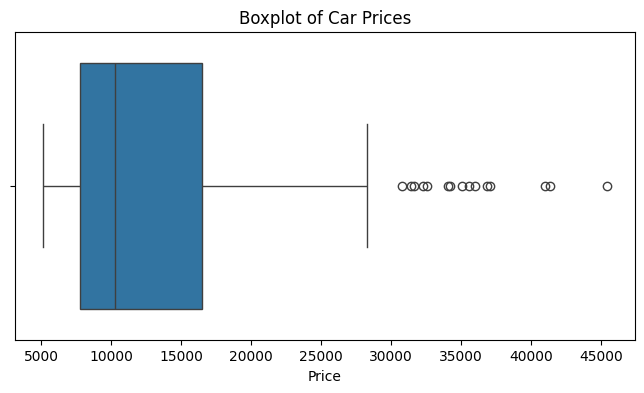

In [15]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['price'])

plt.title('Boxplot of Car Prices')
plt.xlabel('Price')

plt.show()

In [16]:
Q1_price = df['price'].quantile(0.25)
Q3_price = df['price'].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_bound = Q1_price - 1.5 * IQR_price
upper_bound = Q3_price + 1.5 * IQR_price

price_outliers = df[
    (df['price'] < lower_bound) |
    (df['price'] > upper_bound)
]

price_outliers[['car_ID', 'price']]

,car_ID,price
15,16,30760.0
16,17,41315.0
17,18,36880.0
47,48,32250.0
48,49,35550.0
49,50,36000.0
70,71,31600.0
71,72,34184.0
72,73,35056.0
73,74,40960.0


In [17]:
price_outliers[
    ['car_ID', 'price', 'horsepower', 'enginesize', 'curbweight',
     'carbody', 'fueltype']
]

,car_ID,price,horsepower,enginesize,curbweight,carbody,fueltype
15,16,30760.0,182,209,3230,sedan,gas
16,17,41315.0,182,209,3380,sedan,gas
17,18,36880.0,182,209,3505,sedan,gas
47,48,32250.0,176,258,4066,sedan,gas
48,49,35550.0,176,258,4066,sedan,gas
49,50,36000.0,262,326,3950,sedan,gas
70,71,31600.0,123,183,3770,sedan,diesel
71,72,34184.0,155,234,3740,sedan,gas
72,73,35056.0,155,234,3685,convertible,gas
73,74,40960.0,184,308,3900,sedan,gas


---

# Section 2

Section 2 content

---

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [18]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)